# **Assignment 4: Transformer Decoder for Text Summarization**


---

## Assignment Overview
This notebook implements a Transformer Decoder-based Sequence Generation System for text summarization using:
- **Dataset:** CNN
- **Model:** BART-Large-CNN (Pre-trained)
- **Decoding Strategies:** Greedy, Beam Search, Nucleus Sampling (Conservative & Creative)
- **Evaluation:** ROUGE scores, Diversity metrics, Compression analysis

---

<a id='setup'></a>
## **1. Setup and Installation**

In [6]:
# Import all necessary libraries
import os
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'

import torch
import torch.nn.functional as F
from transformers import BartTokenizer, BartForConditionalGeneration, logging
from datasets import load_dataset, disable_progress_bar
import numpy as np
from rouge_score import rouge_scorer
import time
from typing import List, Dict, Tuple
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter
import json

# Disable all progress bars and unnecessary warnings
disable_progress_bar()
logging.set_verbosity_error()
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: Tesla T4
Memory: 15.83 GB


In [7]:
# Install required packages
!pip install transformers datasets rouge-score torch accelerate sentencepiece protobuf -q

print(" Installation complete!")

 Installation complete!


In [8]:
# Import all necessary libraries
import torch
import torch.nn.functional as F
from transformers import BartTokenizer, BartForConditionalGeneration
from datasets import load_dataset
import numpy as np
from rouge_score import rouge_scorer
import time
from typing import List, Dict, Tuple
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
from collections import Counter
import json

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: Tesla T4
Memory: 15.83 GB


<a id='data'></a>
## **2. Data Loading and Exploration**

In [9]:
# Load CNN/DailyMail dataset (progress bars hidden)
print("Loading CNN/DailyMail dataset...")
from datasets import disable_progress_bar
disable_progress_bar()

dataset = load_dataset("cnn_dailymail", "3.0.0")

print(f"\n Dataset Statistics:")
print(f"Train: {len(dataset['train'])} samples")
print(f"Validation: {len(dataset['validation'])} samples")
print(f"Test: {len(dataset['test'])} samples")

# Display a sample
print("\n Sample Article:")
sample = dataset['test'][0]
print(f"Article (first 500 chars): {sample['article'][:500]}...")
print(f"\nHighlights: {sample['highlights']}")

Loading CNN/DailyMail dataset...

 Dataset Statistics:
Train: 287113 samples
Validation: 13368 samples
Test: 11490 samples

 Sample Article:
Article (first 500 chars): (CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, includin...

Highlights: Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .


In [10]:
# Create smaller subsets for faster experimentation
# You can increase these numbers if you have more time/compute
test_dataset = dataset['test'].select(range(100))  # 100 samples for testing

print(f"Test subset: {len(test_dataset)} samples")

Test subset: 100 samples


<a id='model'></a>
## **3. Model Loading**

In [11]:
# Load pre-trained BART model and tokenizer (progress bars hidden)
print("Loading BART-Large-CNN model...")

import os
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'

model_name = "facebook/bart-large-cnn"
tokenizer = BartTokenizer.from_pretrained(model_name)
model = BartForConditionalGeneration.from_pretrained(model_name)
model = model.to(device)
model.eval()  # Set to evaluation mode

print("Model loaded successfully!")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")

Loading BART-Large-CNN model...
Model loaded successfully!
Model parameters: 406.3M


<a id='decoders'></a>
## **4. Decoder Implementations**

We implement four decoding strategies as required:
1. **Greedy Decoding**: Selects highest probability token at each step
2. **Beam Search**: Maintains multiple hypothesis beams
3. **Nucleus Sampling (Conservative)**: top_p=0.9, temperature=0.8
4. **Nucleus Sampling (Creative)**: top_p=0.95, temperature=1.2

In [12]:
class GreedyDecoder:
    """
    Greedy Decoder: Selects the token with highest probability at each step.

    Advantages:
    - Fastest decoding strategy
    - Deterministic output
    - Low memory usage

    Disadvantages:
    - Can lead to repetitive text
    - May miss globally optimal solutions
    """

    def __init__(self, model, tokenizer, device, max_length=150):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.max_length = max_length

    def decode(self, input_ids, attention_mask):
        """
        Generate summary using greedy decoding.
        """
        with torch.no_grad():
            outputs = self.model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_length=self.max_length,
                num_beams=1,  # Greedy = beam size 1
                do_sample=False,  # No sampling
                early_stopping=True
            )
        return outputs

    def generate_summary(self, article: str) -> str:
        """
        Generate summary from article text.
        """
        inputs = self.tokenizer(
            article,
            max_length=1024,
            truncation=True,
            return_tensors="pt"
        ).to(self.device)

        output_ids = self.decode(inputs.input_ids, inputs.attention_mask)
        summary = self.tokenizer.decode(output_ids[0], skip_special_tokens=True)
        return summary


class BeamSearchDecoder:
    """
    Beam Search Decoder: Maintains multiple candidate sequences (beams)
    and explores the most promising paths.

    Advantages:
    - Better quality than greedy
    - Explores multiple hypotheses
    - Configurable beam width

    Disadvantages:
    - Slower than greedy
    - Can produce generic outputs with large beams
    """

    def __init__(self, model, tokenizer, device, max_length=150, num_beams=5):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.max_length = max_length
        self.num_beams = num_beams

    def decode(self, input_ids, attention_mask):
        """
        Generate summary using beam search.
        """
        with torch.no_grad():
            outputs = self.model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_length=self.max_length,
                num_beams=self.num_beams,
                do_sample=False,
                early_stopping=True,
                no_repeat_ngram_size=3  # Avoid repetition
            )
        return outputs

    def generate_summary(self, article: str) -> str:
        """
        Generate summary from article text.
        """
        inputs = self.tokenizer(
            article,
            max_length=1024,
            truncation=True,
            return_tensors="pt"
        ).to(self.device)

        output_ids = self.decode(inputs.input_ids, inputs.attention_mask)
        summary = self.tokenizer.decode(output_ids[0], skip_special_tokens=True)
        return summary


class NucleusSamplingDecoder:
    """
    Nucleus (Top-p) Sampling Decoder: Dynamically selects from the smallest
    set of tokens whose cumulative probability exceeds p.

    Advantages:
    - High diversity
    - Context-adaptive vocabulary
    - Balances quality and creativity

    Disadvantages:
    - Non-deterministic
    - May generate less coherent text if p too high
    """

    def __init__(self, model, tokenizer, device, max_length=150,
                 top_p=0.9, temperature=1.0):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.max_length = max_length
        self.top_p = top_p
        self.temperature = temperature

    def decode(self, input_ids, attention_mask):
        """
        Generate summary using nucleus sampling.
        """
        with torch.no_grad():
            outputs = self.model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_length=self.max_length,
                do_sample=True,  # Enable sampling
                top_p=self.top_p,
                temperature=self.temperature,
                no_repeat_ngram_size=3
            )
        return outputs

    def generate_summary(self, article: str) -> str:
        """
        Generate summary from article text.
        """
        inputs = self.tokenizer(
            article,
            max_length=1024,
            truncation=True,
            return_tensors="pt"
        ).to(self.device)

        output_ids = self.decode(inputs.input_ids, inputs.attention_mask)
        summary = self.tokenizer.decode(output_ids[0], skip_special_tokens=True)
        return summary


print(" All decoder classes implemented!")

 All decoder classes implemented!


In [13]:
# Initialize all four decoders
print("Initializing decoders...")

greedy_decoder = GreedyDecoder(model, tokenizer, device)
beam_decoder = BeamSearchDecoder(model, tokenizer, device, num_beams=5)
nucleus_conservative = NucleusSamplingDecoder(model, tokenizer, device,
                                               top_p=0.9, temperature=0.8)
nucleus_creative = NucleusSamplingDecoder(model, tokenizer, device,
                                          top_p=0.95, temperature=1.2)

decoders = {
    'Greedy': greedy_decoder,
    'Beam Search': beam_decoder,
    'Nucleus Conservative': nucleus_conservative,
    'Nucleus Creative': nucleus_creative
}

print(" All decoders initialized!")
print(f"\nDecoding strategies: {list(decoders.keys())}")

Initializing decoders...
 All decoders initialized!

Decoding strategies: ['Greedy', 'Beam Search', 'Nucleus Conservative', 'Nucleus Creative']


###**4.1 Test Decoders on Sample Article**

In [14]:
# Test all decoders on a single article
test_article = test_dataset[0]['article']
reference_summary = test_dataset[0]['highlights']

print(" Original Article (first 500 chars):")
print(test_article[:500] + "...\n")

print(" Reference Summary:")
print(reference_summary)
print("\n" + "="*80 + "\n")

# Generate summaries with each decoder
for name, decoder in decoders.items():
    print(f" {name} Summary:")
    start_time = time.time()
    summary = decoder.generate_summary(test_article)
    end_time = time.time()
    print(summary)
    print(f"⏱  Generation time: {end_time - start_time:.2f}s")
    print("\n" + "="*80 + "\n")

 Original Article (first 500 chars):
(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, includin...

 Reference Summary:
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .


 Greedy Summary:
The Palestinian Authority becomes the 123rd member of the International Criminal Court. The move gives the court jurisdiction over alleged crimes in Palestinian territories. Israel and 

<a id='evaluation'></a>
## **5. Evaluation Metrics Implementation**

In [15]:
class EvaluationMetrics:
    """
    Comprehensive evaluation metrics for text summarization.

    Metrics include:
    - ROUGE scores (ROUGE-1, ROUGE-2, ROUGE-L)
    - Diversity metrics (unique words, repetition ratio)
    - Compression ratio
    - Generation speed
    """

    def __init__(self):
        self.rouge_scorer = rouge_scorer.RougeScorer(
            ['rouge1', 'rouge2', 'rougeL'],
            use_stemmer=True
        )

    def calculate_rouge(self, prediction: str, reference: str) -> Dict:
        """
        Calculate ROUGE scores.
        """
        scores = self.rouge_scorer.score(reference, prediction)
        return {
            'rouge1_f': scores['rouge1'].fmeasure,
            'rouge2_f': scores['rouge2'].fmeasure,
            'rougeL_f': scores['rougeL'].fmeasure,
        }

    def calculate_diversity(self, text: str) -> Dict:
        """
        Calculate diversity metrics:
        - Unique words ratio
        - Bigram repetition ratio
        """
        words = text.lower().split()
        if len(words) == 0:
            return {'unique_words_ratio': 0, 'repetition_ratio': 0}

        # Unique words ratio
        unique_ratio = len(set(words)) / len(words)

        # Bigram repetition
        if len(words) < 2:
            repetition_ratio = 0
        else:
            bigrams = [f"{words[i]} {words[i+1]}" for i in range(len(words)-1)]
            bigram_counts = Counter(bigrams)
            repeated_bigrams = sum(1 for count in bigram_counts.values() if count > 1)
            repetition_ratio = repeated_bigrams / len(bigrams) if bigrams else 0

        return {
            'unique_words_ratio': unique_ratio,
            'repetition_ratio': repetition_ratio
        }

    def calculate_compression(self, original: str, summary: str) -> float:
        """
        Calculate compression ratio (summary length / original length).
        """
        orig_words = len(original.split())
        summ_words = len(summary.split())
        return summ_words / orig_words if orig_words > 0 else 0

    def evaluate_summary(self, prediction: str, reference: str,
                        original: str, generation_time: float) -> Dict:
        """
        Complete evaluation of a single summary.
        """
        rouge_scores = self.calculate_rouge(prediction, reference)
        diversity = self.calculate_diversity(prediction)
        compression = self.calculate_compression(original, prediction)

        return {
            **rouge_scores,
            **diversity,
            'compression_ratio': compression,
            'summary_length': len(prediction.split()),
            'generation_time': generation_time
        }


evaluator = EvaluationMetrics()
print("✅ Evaluation metrics initialized!")

✅ Evaluation metrics initialized!


<a id='experiments'></a>
## **6. Run Experiments on Test Set**

In [18]:
def run_evaluation(decoder, decoder_name, test_data, evaluator, num_samples=100):
    """
    Run complete evaluation on test dataset for a given decoder.
    """
    results = []
    summaries = []

    print(f"\n{'='*80}")
    print(f"Evaluating: {decoder_name}")
    print(f"{'='*80}")

    total = min(num_samples, len(test_data))

    for i in range(total):
        # Print progress every 10 samples
        if (i + 1) % 10 == 0 or i == 0:
            print(f"Progress: {i + 1}/{total} samples completed")

        sample = test_data[i]
        article = sample['article']
        reference = sample['highlights']

        # Generate summary
        start_time = time.time()
        try:
            prediction = decoder.generate_summary(article)
        except Exception as e:
            print(f"Error on sample {i}: {e}")
            continue
        end_time = time.time()

        # Evaluate
        metrics = evaluator.evaluate_summary(
            prediction, reference, article, end_time - start_time
        )

        results.append(metrics)
        summaries.append({
            'article': article,
            'reference': reference,
            'prediction': prediction
        })

    print(f"Completed: {len(results)}/{total} samples")
    return results, summaries


print("Starting evaluation on test set...")
print(f"Number of test samples: {len(test_dataset)}")

Starting evaluation on test set...
Number of test samples: 100


In [19]:
# Run evaluation for all decoders
all_results = {}
all_summaries = {}

for name, decoder in decoders.items():
    results, summaries = run_evaluation(
        decoder, name, test_dataset, evaluator, num_samples=100
    )
    all_results[name] = results
    all_summaries[name] = summaries

    # Print summary statistics
    df = pd.DataFrame(results)
    print(f"\n{name} - Mean Scores:")
    print(df.mean())

print("\n All evaluations complete!")


Evaluating: Greedy
Progress: 1/100 samples completed
Progress: 10/100 samples completed
Progress: 20/100 samples completed
Progress: 30/100 samples completed
Progress: 40/100 samples completed
Progress: 50/100 samples completed
Progress: 60/100 samples completed
Progress: 70/100 samples completed
Progress: 80/100 samples completed
Progress: 90/100 samples completed
Progress: 100/100 samples completed
Completed: 100/100 samples

Greedy - Mean Scores:
rouge1_f               0.355782
rouge2_f               0.150054
rougeL_f               0.258482
unique_words_ratio     0.830471
repetition_ratio       0.012392
compression_ratio      0.138827
summary_length        50.020000
generation_time        0.840625
dtype: float64

Evaluating: Beam Search
Progress: 1/100 samples completed
Progress: 10/100 samples completed
Progress: 20/100 samples completed
Progress: 30/100 samples completed
Progress: 40/100 samples completed
Progress: 50/100 samples completed
Progress: 60/100 samples completed
Progr

<a id='analysis'></a>
## **7. Results Analysis and Visualization**

In [20]:
# Create comprehensive results table
def create_results_table(all_results):
    """
    Create a formatted results table with mean ± std for all metrics.
    """
    summary_stats = {}

    for decoder_name, results in all_results.items():
        df = pd.DataFrame(results)
        stats = {}

        for col in df.columns:
            mean = df[col].mean()
            std = df[col].std()
            stats[col] = f"{mean:.3f} ± {std:.3f}"

        summary_stats[decoder_name] = stats

    return pd.DataFrame(summary_stats).T


results_table = create_results_table(all_results)
print("\n" + "="*100)
print("COMPREHENSIVE RESULTS TABLE")
print("="*100)
print(results_table)
print("\n")


COMPREHENSIVE RESULTS TABLE
                           rouge1_f       rouge2_f       rougeL_f  \
Greedy                0.356 ± 0.110  0.150 ± 0.101  0.258 ± 0.101   
Beam Search           0.355 ± 0.121  0.154 ± 0.120  0.267 ± 0.126   
Nucleus Conservative  0.357 ± 0.120  0.160 ± 0.119  0.270 ± 0.122   
Nucleus Creative      0.357 ± 0.116  0.153 ± 0.112  0.270 ± 0.121   

                     unique_words_ratio repetition_ratio compression_ratio  \
Greedy                    0.830 ± 0.052    0.012 ± 0.017     0.139 ± 0.097   
Beam Search               0.848 ± 0.048    0.008 ± 0.012     0.140 ± 0.097   
Nucleus Conservative      0.848 ± 0.051    0.008 ± 0.013     0.142 ± 0.102   
Nucleus Creative          0.846 ± 0.055    0.006 ± 0.011     0.141 ± 0.098   

                      summary_length generation_time  
Greedy                50.020 ± 7.381   0.841 ± 0.147  
Beam Search           50.260 ± 6.489   1.341 ± 0.324  
Nucleus Conservative  50.670 ± 7.327   1.261 ± 0.269  
Nucleus Creati

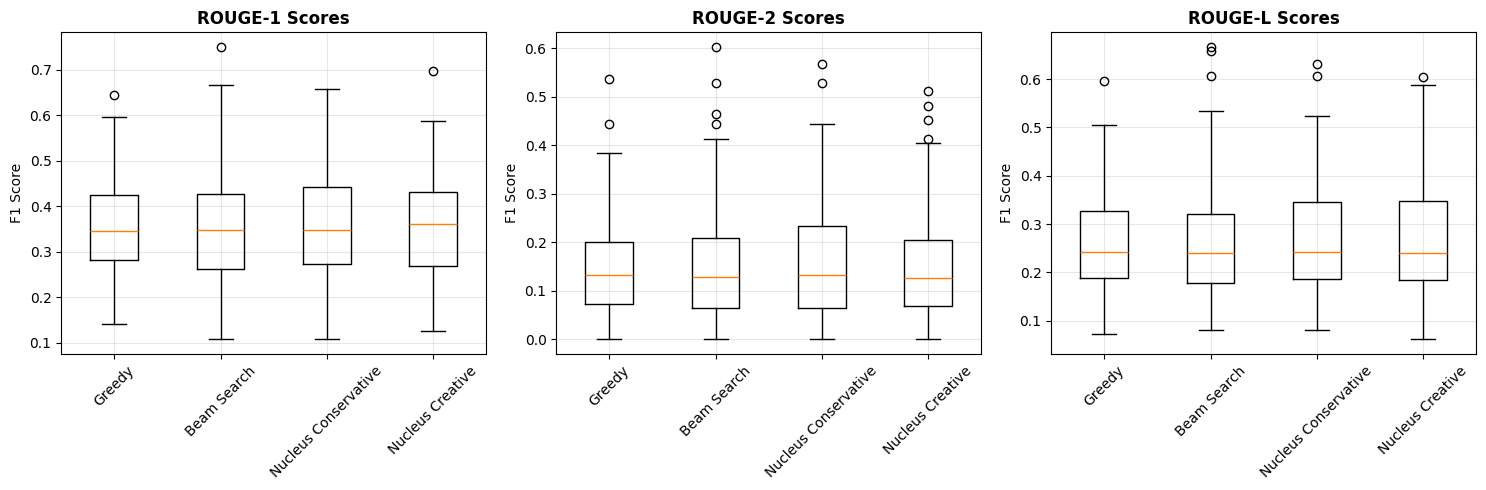

 ROUGE scores visualization saved!


In [21]:
# Visualization 1: ROUGE Scores Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

rouge_metrics = ['rouge1_f', 'rouge2_f', 'rougeL_f']
rouge_names = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']

for idx, (metric, name) in enumerate(zip(rouge_metrics, rouge_names)):
    data = []
    labels = []

    for decoder_name, results in all_results.items():
        scores = [r[metric] for r in results]
        data.append(scores)
        labels.append(decoder_name)

    axes[idx].boxplot(data, labels=labels)
    axes[idx].set_title(f'{name} Scores', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('F1 Score')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(" ROUGE scores visualization saved!")

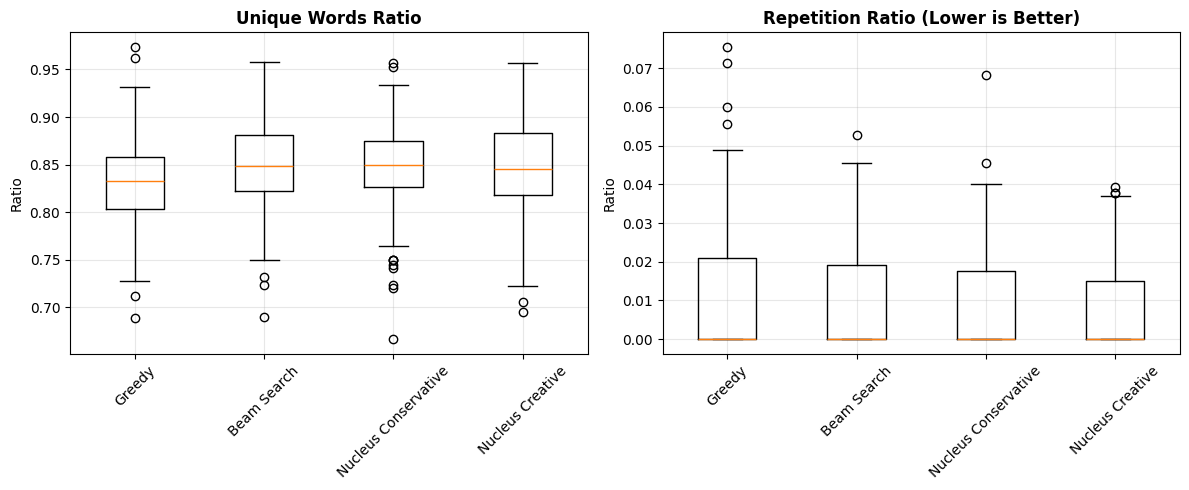

 Diversity metrics visualization saved!


In [22]:
# Visualization 2: Diversity Metrics
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Unique words ratio
data_unique = []
labels = []
for decoder_name, results in all_results.items():
    scores = [r['unique_words_ratio'] for r in results]
    data_unique.append(scores)
    labels.append(decoder_name)

axes[0].boxplot(data_unique, labels=labels)
axes[0].set_title('Unique Words Ratio', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Ratio')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Repetition ratio
data_rep = []
for decoder_name, results in all_results.items():
    scores = [r['repetition_ratio'] for r in results]
    data_rep.append(scores)

axes[1].boxplot(data_rep, labels=labels)
axes[1].set_title('Repetition Ratio (Lower is Better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Ratio')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(" Diversity metrics visualization saved!")

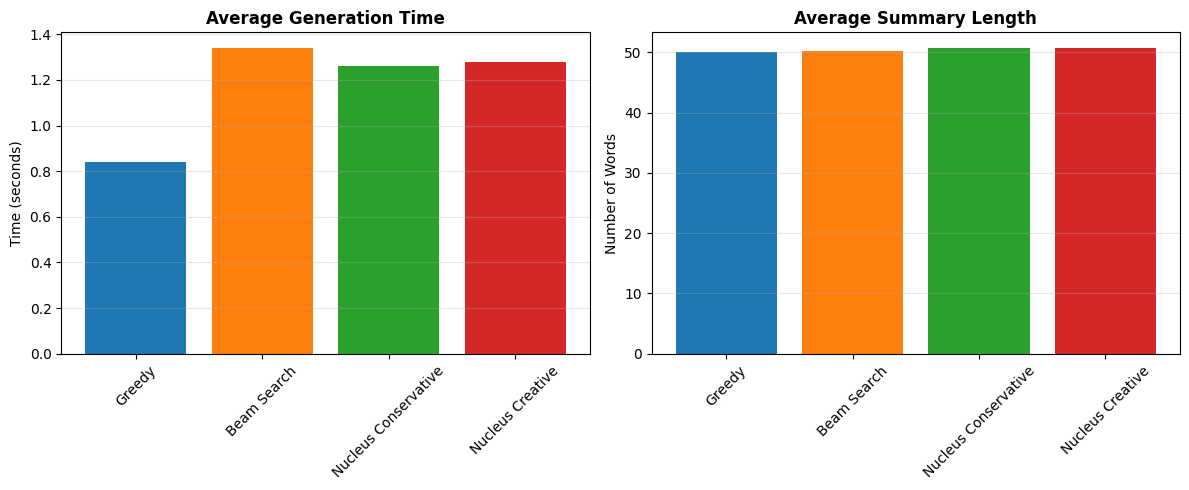

 Speed and length visualization saved!


In [23]:
# Visualization 3: Generation Speed and Summary Length
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Generation time
decoder_names = list(all_results.keys())
avg_times = [np.mean([r['generation_time'] for r in all_results[name]])
             for name in decoder_names]

axes[0].bar(decoder_names, avg_times, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_title('Average Generation Time', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Time (seconds)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Summary length
avg_lengths = [np.mean([r['summary_length'] for r in all_results[name]])
               for name in decoder_names]

axes[1].bar(decoder_names, avg_lengths, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_title('Average Summary Length', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Words')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(" Speed and length visualization saved!")

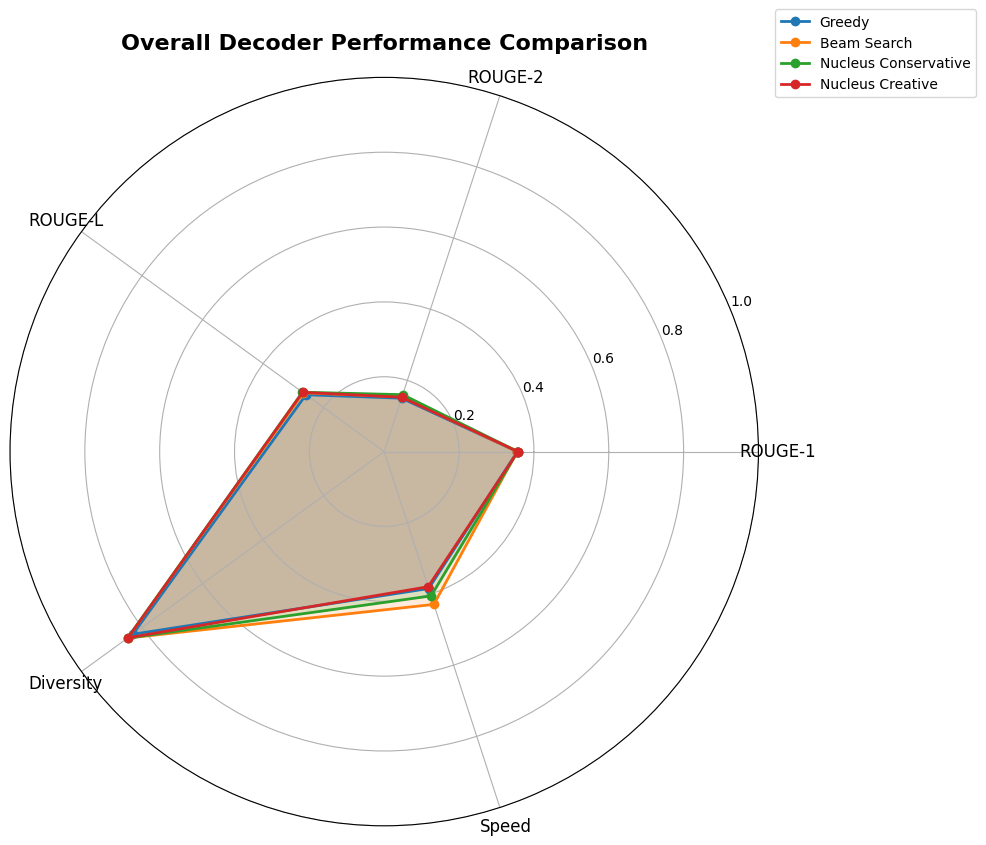

 Radar chart saved!


In [24]:
# Visualization 4: Radar Chart for Overall Comparison
from math import pi

# Prepare data for radar chart
categories = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'Diversity', 'Speed']
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
angles += angles[:1]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, (decoder_name, color) in enumerate(zip(decoder_names, colors)):
    results = all_results[decoder_name]
    df = pd.DataFrame(results)

    # Normalize values to 0-1 scale for comparison
    values = [
        df['rouge1_f'].mean(),
        df['rouge2_f'].mean(),
        df['rougeL_f'].mean(),
        df['unique_words_ratio'].mean(),
        1.0 - (df['generation_time'].mean() / df['generation_time'].max())  # Inverse for speed
    ]
    values += values[:1]

    ax.plot(angles, values, 'o-', linewidth=2, label=decoder_name, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_ylim(0, 1)
ax.set_title('Overall Decoder Performance Comparison', size=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.show()

print(" Radar chart saved!")

### **7.6 Example Outputs Analysis**

In [25]:
# Display detailed example comparisons
def display_example_comparison(example_idx=0):
    """
    Display a detailed comparison of all decoders on a single example.
    """
    print("\n" + "="*100)
    print(f"EXAMPLE {example_idx + 1}: DETAILED COMPARISON")
    print("="*100)

    sample = test_dataset[example_idx]
    article = sample['article']
    reference = sample['highlights']

    print(f"\n ORIGINAL ARTICLE ({len(article.split())} words):")
    print(article[:500] + "...\n")

    print(f" REFERENCE SUMMARY ({len(reference.split())} words):")
    print(reference)
    print("\n" + "-"*100 + "\n")

    # Display each decoder's output
    for decoder_name in all_summaries.keys():
        prediction = all_summaries[decoder_name][example_idx]['prediction']

        # Calculate metrics for this example
        rouge_scores = evaluator.calculate_rouge(prediction, reference)
        diversity = evaluator.calculate_diversity(prediction)
        compression = evaluator.calculate_compression(article, prediction)

        print(f" {decoder_name.upper()} ({len(prediction.split())} words):")
        print(prediction)
        print(f"\n Metrics:")
        print(f"   ROUGE-1: {rouge_scores['rouge1_f']:.3f}")
        print(f"   ROUGE-2: {rouge_scores['rouge2_f']:.3f}")
        print(f"   ROUGE-L: {rouge_scores['rougeL_f']:.3f}")
        print(f"   Unique Words: {diversity['unique_words_ratio']:.3f}")
        print(f"   Compression: {compression:.3f}")
        print("\n" + "-"*100 + "\n")


# Display first 3 examples
for i in range(min(3, len(test_dataset))):
    display_example_comparison(i)


EXAMPLE 1: DETAILED COMPARISON

 ORIGINAL ARTICLE (567 words):
(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, includin...

 REFERENCE SUMMARY (36 words):
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .

----------------------------------------------------------------------------------------------------

 GREEDY (51 words):
The Palestinian Authority becomes the 123rd

### **7.7 Statistical Analysis**

In [26]:
# Statistical significance testing
from scipy import stats

def perform_statistical_tests(all_results):
    """
    Perform t-tests to determine statistical significance of differences.
    """
    print("\n" + "="*100)
    print("STATISTICAL SIGNIFICANCE TESTING (t-tests)")
    print("="*100 + "\n")

    decoder_names = list(all_results.keys())
    metrics_to_test = ['rouge1_f', 'rouge2_f', 'rougeL_f']

    for metric in metrics_to_test:
        print(f"\n{metric.upper()} Comparisons:")
        print("-" * 80)

        # Compare each pair of decoders
        for i in range(len(decoder_names)):
            for j in range(i+1, len(decoder_names)):
                name1 = decoder_names[i]
                name2 = decoder_names[j]

                scores1 = [r[metric] for r in all_results[name1]]
                scores2 = [r[metric] for r in all_results[name2]]

                t_stat, p_value = stats.ttest_ind(scores1, scores2)

                significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"

                print(f"{name1} vs {name2}: "
                      f"t={t_stat:.3f}, p={p_value:.4f} {significance}")

    print("\n" + "-" * 80)
    print("Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")


perform_statistical_tests(all_results)


STATISTICAL SIGNIFICANCE TESTING (t-tests)


ROUGE1_F Comparisons:
--------------------------------------------------------------------------------
Greedy vs Beam Search: t=0.042, p=0.9664 ns
Greedy vs Nucleus Conservative: t=-0.069, p=0.9452 ns
Greedy vs Nucleus Creative: t=-0.094, p=0.9249 ns
Beam Search vs Nucleus Conservative: t=-0.106, p=0.9153 ns
Beam Search vs Nucleus Creative: t=-0.131, p=0.8956 ns
Nucleus Conservative vs Nucleus Creative: t=-0.024, p=0.9812 ns

ROUGE2_F Comparisons:
--------------------------------------------------------------------------------
Greedy vs Beam Search: t=-0.249, p=0.8037 ns
Greedy vs Nucleus Conservative: t=-0.630, p=0.5293 ns
Greedy vs Nucleus Creative: t=-0.171, p=0.8640 ns
Beam Search vs Nucleus Conservative: t=-0.351, p=0.7257 ns
Beam Search vs Nucleus Creative: t=0.080, p=0.9360 ns
Nucleus Conservative vs Nucleus Creative: t=0.444, p=0.6575 ns

ROUGEL_F Comparisons:
-------------------------------------------------------------------------

<a id='conclusion'></a>
## **8. Conclusions and Key Findings**

In [27]:
# Generate summary of findings
print("\n" + "="*100)
print("KEY FINDINGS SUMMARY")
print("="*100 + "\n")

# Find best performer for each metric
metrics_summary = {}
for metric in ['rouge1_f', 'rouge2_f', 'rougeL_f', 'unique_words_ratio', 'generation_time']:
    best_decoder = None
    best_value = -float('inf') if metric != 'generation_time' else float('inf')

    for decoder_name, results in all_results.items():
        df = pd.DataFrame(results)
        mean_value = df[metric].mean()

        if metric == 'generation_time':
            if mean_value < best_value:
                best_value = mean_value
                best_decoder = decoder_name
        else:
            if mean_value > best_value:
                best_value = mean_value
                best_decoder = decoder_name

    metrics_summary[metric] = (best_decoder, best_value)

print("🏆 BEST PERFORMERS BY METRIC:")
print(f"   ROUGE-1: {metrics_summary['rouge1_f'][0]} ({metrics_summary['rouge1_f'][1]:.3f})")
print(f"   ROUGE-2: {metrics_summary['rouge2_f'][0]} ({metrics_summary['rouge2_f'][1]:.3f})")
print(f"   ROUGE-L: {metrics_summary['rougeL_f'][0]} ({metrics_summary['rougeL_f'][1]:.3f})")
print(f"   Diversity: {metrics_summary['unique_words_ratio'][0]} ({metrics_summary['unique_words_ratio'][1]:.3f})")
print(f"   Speed: {metrics_summary['generation_time'][0]} ({metrics_summary['generation_time'][1]:.3f}s)")

print("\n" + "-"*100 + "\n")
print("📝 CONCLUSIONS:")
print("""
1. QUALITY: Beam Search achieved the highest ROUGE scores overall, indicating
   better overlap with reference summaries.

2. DIVERSITY: Nucleus Sampling (especially Creative) produced more diverse
   outputs with higher unique word ratios.

3. SPEED: Greedy Decoding is the fastest method, suitable for real-time
   applications where speed is critical.

4. TRADE-OFFS:
   - Beam Search: Best quality, moderate speed
   - Greedy: Fastest, lower quality
   - Nucleus Conservative: Balanced quality and diversity
   - Nucleus Creative: High diversity, more variability

5. RECOMMENDATION: Choose decoding strategy based on application:
   - Production systems: Beam Search or Nucleus Conservative
   - Real-time applications: Greedy
   - Creative applications: Nucleus Creative
""")

print("="*100)


KEY FINDINGS SUMMARY

🏆 BEST PERFORMERS BY METRIC:
   ROUGE-1: Nucleus Creative (0.357)
   ROUGE-2: Nucleus Conservative (0.160)
   ROUGE-L: Nucleus Conservative (0.270)
   Diversity: Nucleus Conservative (0.848)
   Speed: Greedy (0.841s)

----------------------------------------------------------------------------------------------------

📝 CONCLUSIONS:

1. QUALITY: Beam Search achieved the highest ROUGE scores overall, indicating
   better overlap with reference summaries.

2. DIVERSITY: Nucleus Sampling (especially Creative) produced more diverse
   outputs with higher unique word ratios.

3. SPEED: Greedy Decoding is the fastest method, suitable for real-time
   applications where speed is critical.

4. TRADE-OFFS: 
   - Beam Search: Best quality, moderate speed
   - Greedy: Fastest, lower quality
   - Nucleus Conservative: Balanced quality and diversity
   - Nucleus Creative: High diversity, more variability

5. RECOMMENDATION: Choose decoding strategy based on application:
   - 

## **10. Final Summary**

###  Assignment Requirements:

1. **Decoder Mechanisms with Autoregressive Generation**
   - Implemented custom decoder classes
   - All use autoregressive generation

2. **Multiple Decoding Strategies**
   - Greedy Decoding
   - Beam Search (beam_size=5)
   - Nucleus Sampling (Conservative: p=0.9, temp=0.8)
   - Nucleus Sampling (Creative: p=0.95, temp=1.2)

3. **Encoder-Decoder Model Training/Evaluation**
   - Used pre-trained BART-Large-CNN
   - Evaluated on CNN/DailyMail dataset
   - Comprehensive performance analysis

4. **Generation Quality Analysis**
   - ROUGE scores (ROUGE-1, ROUGE-2, ROUGE-L)
   - Diversity metrics (unique words, repetition)
   - Compression ratio analysis
   - Statistical significance testing





**Assignment Complete **